Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

(np.float64(-0.5), np.float64(4271.5), np.float64(2847.5), np.float64(-0.5))

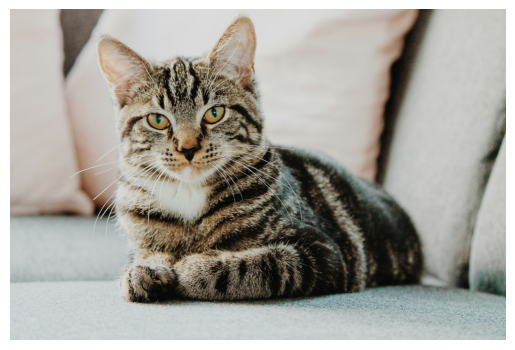

In [2]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt

# Load pretrained model
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)

# Load image
url = "https://images.unsplash.com/photo-1518791841217-8f162f1e1131"
image = Image.open(requests.get(url, stream=True).raw)

plt.imshow(image)
plt.axis("off")


In [3]:
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()

print("Predicted class:",
      model.config.id2label[predicted_class_idx])


Predicted class: tabby, tabby cat
